# Phase 3 — XGBoost + Optuna on Morgan FP + RDKit descriptors

Same featurization as Phase 2 (`02b`): **Morgan FP (radius=2, 2048 bits) ⊕ RDKit 2D descriptors (217 features)**.
Same evaluation protocols as Phase 1/2: **random split + balanced scaffold split, multi-seed**.

**What changes**: the model. Random Forest → XGBoost, with hyperparameters chosen by **Optuna** via
**scaffold-aware 5-fold cross-validation** on the training set only (no leakage from valid/test).

**Hypothesis**: tuned XGBoost beats untuned RF aggregate by ~0.05–0.10 RMSE on the 5-seed scaffold mean,
but the **sugar bias** documented in Phase 2 stays: it is a property of the *featurization*
(global descriptors enabling a 'MW + ring count → low logS' shortcut), not of the model. Verified explicitly
in §11.

**Methodological choices for this notebook**:
- **Optuna objective**: scaffold-aware 5-fold CV mean RMSE on training set.
- **Search space**: 9 hyperparameters (`n_estimators`, `max_depth`, `learning_rate`, `subsample`,
  `colsample_bytree`, `min_child_weight`, `reg_lambda`, `reg_alpha`, `gamma`).
- **Budget**: 100 trials, TPE sampler, MedianPruner.
- **XGBoost `random_state=42`** kept fixed across all multi-seed runs (only the data split varies with the seed,
  exactly as in Phase 1/2 — the model's internal randomness stays constant for clean attribution).


## 1. Setup

In [ ]:
import os
from pathlib import Path

# Detect runtime environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/qsar-esol-solubility')
else:
    PROJECT_ROOT = Path.cwd().parent

DATA_DIR      = PROJECT_ROOT / 'data'
RAW_DIR       = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR    = PROJECT_ROOT / 'models'
REPORTS_DIR   = PROJECT_ROOT / 'reports'

for d in [RAW_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")
print(f"Project root: {PROJECT_ROOT}")


Mounted at /content/drive
Environment: Colab
Project root: /content/drive/MyDrive/qsar-esol-solubility


In [ ]:
# In Colab, install rdkit + xgboost + optuna. Locally these should already be in the venv.
if IN_COLAB:
    !pip install rdkit xgboost optuna -q

import warnings
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import time
import json
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

RDLogger.DisableLog('rdApp.*')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"xgboost: {xgb.__version__}")
print(f"optuna:  {optuna.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.5 MB/s eta 0:00:00
xgboost: 3.2.0
optuna:  4.8.0


## 2. Load deduplicated dataset

Identical to notebook 02b: load `esol_dedup.csv` (1117 mols), rebuild Mol objects on the fly.


In [ ]:
df = pd.read_csv(PROCESSED_DIR / 'esol_dedup.csv')
print(f"Loaded {len(df)} molecules")
print(f"Columns: {list(df.columns)}")

df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
n_failed = df['mol'].isna().sum()
assert n_failed == 0, f"{n_failed} SMILES failed to parse"
print("All SMILES parsed correctly.")

df.head()


Loaded 1117 molecules
Columns: ['smiles', 'logS']
All SMILES parsed correctly.


,smiles,logS,mol
0,BrC(Br)(Br)Br,-3.14,<rdkit.Chem.rdchem.Mol object at 0x793df756db60>
1,BrC(Br)Br,-1.91,<rdkit.Chem.rdchem.Mol object at 0x793df756dbd0>
2,BrCBr,-1.17,<rdkit.Chem.rdchem.Mol object at 0x793df756dc40>
3,BrCCBr,-1.68,<rdkit.Chem.rdchem.Mol object at 0x793df756dcb0>
4,Brc1cc(Br)c(Br)cc1Br,-6.98,<rdkit.Chem.rdchem.Mol object at 0x793df756dd20>


## 3. Featurization (same as Phase 2)

Morgan FP 2048 ⊕ RDKit 2D descriptors (217). Median imputation fitted on training fold only.
These helpers are copied verbatim from notebook 02b for strict comparability — they will be
extracted to `src/featurization.py` once a third notebook reuses them.


In [ ]:
def morgan_fingerprint(mol, radius=2, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def featurize_morgan(df, mol_col='mol', radius=2, n_bits=2048):
    return np.stack([morgan_fingerprint(m, radius, n_bits) for m in df[mol_col]])


DESC_LIST  = [(name, fn) for name, fn in Descriptors._descList]
DESC_NAMES = [name for name, _ in DESC_LIST]
print(f"Number of RDKit 2D descriptors available: {len(DESC_NAMES)}")


def rdkit_descriptors(mol):
    out = np.full(len(DESC_LIST), np.nan, dtype=np.float64)
    if mol is None:
        return out
    for j, (_, fn) in enumerate(DESC_LIST):
        try:
            v = fn(mol)
            if not np.isfinite(v):
                v = np.nan
            out[j] = v
        except Exception:
            out[j] = np.nan
    return out


def featurize_rdkit_descriptors(df, mol_col='mol'):
    return np.stack([rdkit_descriptors(m) for m in df[mol_col]])


def featurize_combined(df, mol_col='mol', radius=2, n_bits=2048):
    fp   = featurize_morgan(df, mol_col, radius, n_bits)
    desc = featurize_rdkit_descriptors(df, mol_col)
    return np.hstack([fp, desc]).astype(np.float64)


def fit_median_imputer(X_train):
    col_all_nan = np.isnan(X_train).all(axis=0)
    keep = ~col_all_nan
    medians = np.nanmedian(X_train[:, keep], axis=0)
    return medians, keep


def apply_imputer(X, medians, keep):
    Xk = X[:, keep]
    nan_mask = np.isnan(Xk)
    if nan_mask.any():
        Xk = Xk.copy()
        Xk[nan_mask] = np.take(medians, np.where(nan_mask)[1])
    return Xk


Number of RDKit 2D descriptors available: 217


## 4. Scaffold split + scaffold-aware k-fold CV

`get_scaffold` and `scaffold_split_balanced` are identical to notebook 02b.

**New here**: `scaffold_kfold` — assigns scaffold groups to k folds via greedy bin-packing
(largest groups first, each goes to the currently smallest fold). This produces folds of comparable
size with **disjoint scaffold sets**, which is the right inner CV protocol when the outer split
is also scaffold-based.


In [ ]:
def get_scaffold(mol, include_chirality=False):
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=include_chirality)


def scaffold_split_balanced(df, mol_col='mol',
                            train_frac=0.8, valid_frac=0.1, test_frac=0.1,
                            seed=42):
    """Balanced (ChemProp-style) scaffold split — same as notebook 02b."""
    assert abs(train_frac + valid_frac + test_frac - 1.0) < 1e-6

    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        scaffolds[get_scaffold(row[mol_col])].append(idx)

    big_groups       = [g for g in scaffolds.values() if len(g) > 1]
    singleton_groups = [g for g in scaffolds.values() if len(g) == 1]

    big_groups.sort(key=lambda g: (len(g), g[0]), reverse=True)
    rng = random.Random(seed)
    rng.shuffle(singleton_groups)

    ordered_groups = big_groups + singleton_groups

    n_total        = len(df)
    n_train_target = int(train_frac * n_total)
    n_valid_target = int(valid_frac * n_total)

    train_idx, valid_idx, test_idx = [], [], []
    for group in ordered_groups:
        if len(train_idx) + len(group) <= n_train_target:
            train_idx.extend(group)
        elif len(valid_idx) + len(group) <= n_valid_target:
            valid_idx.extend(group)
        else:
            test_idx.extend(group)

    return train_idx, valid_idx, test_idx


def scaffold_kfold(df_train, mol_col='mol', n_folds=5, seed=42):
    """
    Scaffold-aware k-fold split for cross-validation on a training subset.

    Strategy:
      1. Group all molecules by Bemis-Murcko scaffold.
      2. Sort scaffold groups by size (largest first).
      3. Greedy bin-packing: assign each group to the currently smallest fold.
         Singleton groups are shuffled with the given seed before being added
         to the queue, to introduce reproducible randomness without breaking
         scaffold disjointness.

    Returns: list of (val_idx_in_df_train,) numpy arrays, one per fold.
    The corresponding train indices are simply the complement.
    """
    scaffolds = defaultdict(list)
    # Use POSITIONAL indices (0..len(df_train)-1), since downstream code
    # will index into reset-indexed arrays X_train / y_train.
    for pos, (_, row) in enumerate(df_train.iterrows()):
        scaffolds[get_scaffold(row[mol_col])].append(pos)

    big_groups       = [g for g in scaffolds.values() if len(g) > 1]
    singleton_groups = [g for g in scaffolds.values() if len(g) == 1]

    big_groups.sort(key=lambda g: (len(g), g[0]), reverse=True)
    rng = random.Random(seed)
    rng.shuffle(singleton_groups)

    ordered_groups = big_groups + singleton_groups

    folds = [[] for _ in range(n_folds)]
    fold_sizes = [0] * n_folds

    for group in ordered_groups:
        # assign to smallest fold (ties broken by lowest index for determinism)
        target = min(range(n_folds), key=lambda i: (fold_sizes[i], i))
        folds[target].extend(group)
        fold_sizes[target] += len(group)

    return [np.array(sorted(f)) for f in folds]


## 5. Outer split (seed=42) and featurization

Optuna is run on this single split. The training set is then sub-divided into 5 scaffold-disjoint folds
for the inner CV objective. The valid/test sets are **never used by Optuna** — they only show up in §10.


In [ ]:
train_idx_b, valid_idx_b, test_idx_b = scaffold_split_balanced(df, seed=RANDOM_SEED)

df_train = df.loc[train_idx_b].reset_index(drop=True)
df_valid = df.loc[valid_idx_b].reset_index(drop=True)
df_test  = df.loc[test_idx_b].reset_index(drop=True)

print(f"Outer scaffold split (seed={RANDOM_SEED}):")
print(f"  Train: {len(df_train)}  |  Valid: {len(df_valid)}  |  Test: {len(df_test)}")

# Featurize once for the outer split
X_train_full = featurize_combined(df_train)
X_valid_full = featurize_combined(df_valid)
X_test_full  = featurize_combined(df_test)
y_train = df_train['logS'].values
y_valid = df_valid['logS'].values
y_test  = df_test['logS'].values

# Fit imputer on TRAIN ONLY (consistent with Phase 2)
medians, keep = fit_median_imputer(X_train_full)
X_train = apply_imputer(X_train_full, medians, keep)
X_valid = apply_imputer(X_valid_full, medians, keep)
X_test  = apply_imputer(X_test_full,  medians, keep)

n_kept_desc = int(keep[2048:].sum())
print(f"\nFeature matrix shape: {X_train.shape}  (Morgan 2048 + Desc {n_kept_desc}/{len(DESC_LIST)})")

# Build the inner 5-fold CV index list once
cv_folds = scaffold_kfold(df_train, n_folds=5, seed=RANDOM_SEED)
for i, f in enumerate(cv_folds):
    print(f"  CV fold {i}: {len(f)} molecules")


Outer scaffold split (seed=42):
  Train: 893  |  Valid: 111  |  Test: 113

Feature matrix shape: (893, 2265)  (Morgan 2048 + Desc 217/217)
  CV fold 0: 316 molecules
  CV fold 1: 253 molecules
  CV fold 2: 108 molecules
  CV fold 3: 108 molecules
  CV fold 4: 108 molecules


## 6. Untuned XGBoost baseline

Sanity check before tuning: out-of-the-box XGBoost on the same outer split, default-ish hyperparameters.
Confirms the pipeline works and gives Optuna a number to beat.


In [ ]:
def evaluate(model, X, y, split_name):
    y_pred = model.predict(X)
    return {
        'split': split_name,
        'RMSE': float(np.sqrt(mean_squared_error(y, y_pred))),
        'MAE':  float(mean_absolute_error(y, y_pred)),
        'R2':   float(r2_score(y, y_pred)),
        'y_true': y,
        'y_pred': y_pred,
    }


xgb_default = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbosity=0,
)

t0 = time.time()
xgb_default.fit(X_train, y_train)
t_default = time.time() - t0

print(f"Untuned XGBoost — fit in {t_default:.1f}s")
print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 32)
for name, X_, y_ in [('train', X_train, y_train),
                       ('valid', X_valid, y_valid),
                       ('test',  X_test,  y_test)]:
    r = evaluate(xgb_default, X_, y_, name)
    print(f"{name:<8} {r['RMSE']:>7.3f} {r['MAE']:>7.3f} {r['R2']:>7.3f}")


Untuned XGBoost — fit in 5.3s
Split       RMSE     MAE      R²
--------------------------------
train      0.009   0.007   1.000
valid      0.823   0.604   0.854
test       0.917   0.714   0.767


## 7. Optuna tuning

**Objective**: mean RMSE across 5 scaffold-disjoint CV folds on the training set.

**Search space (9 hyperparameters)**:

| Param              | Type   | Range            | Why                                      |
|--------------------|--------|------------------|------------------------------------------|
| `n_estimators`     | int    | 200 – 2000       | More trees with smaller LR usually wins  |
| `max_depth`        | int    | 3 – 10           | Trade-off bias / overfit                 |
| `learning_rate`    | log    | 0.01 – 0.3       | Smaller LR + more trees                  |
| `subsample`        | float  | 0.5 – 1.0        | Row sub-sampling regularization          |
| `colsample_bytree` | float  | 0.4 – 1.0        | Column sub-sampling: matters with 2265 features |
| `min_child_weight` | int    | 1 – 10           | Min sum of instance weight per leaf      |
| `reg_lambda`       | log    | 1e-3 – 10        | L2 on weights                            |
| `reg_alpha`        | log    | 1e-3 – 10        | L1 on weights → feature selection effect |
| `gamma`            | log    | 1e-3 – 5         | Min loss reduction to split              |

**Sampler**: TPE (Bayesian-like, default Optuna sampler).
**Pruner**: MedianPruner — kills a trial early if its CV-fold-so-far is worse than the median of past trials at the same fold step. Reports intermediate CV-fold RMSE values via `trial.report(...)`.

**Budget**: 100 trials × 5 folds = 500 fits. Expect ~25–45 minutes on Colab depending on hardware.


In [ ]:
def cv_objective(params, X, y, cv_folds, seed=RANDOM_SEED, trial=None):
    """
    Run scaffold-aware 5-fold CV, return mean RMSE across folds.
    Reports intermediate values so MedianPruner can prune bad trials early.
    """
    fold_rmses = []
    for fold_id, val_idx in enumerate(cv_folds):
        train_mask = np.ones(len(X), dtype=bool)
        train_mask[val_idx] = False
        X_tr, X_val = X[train_mask], X[val_idx]
        y_tr, y_val = y[train_mask], y[val_idx]

        model = xgb.XGBRegressor(
            **params,
            objective='reg:squarederror',
            tree_method='hist',
            n_jobs=-1,
            random_state=seed,
            verbosity=0,
        )
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
        fold_rmses.append(rmse)

        # Report intermediate value for pruning
        if trial is not None:
            running_mean = float(np.mean(fold_rmses))
            trial.report(running_mean, step=fold_id)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return float(np.mean(fold_rmses))


def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 2000, step=50),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha',  1e-3, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma',      1e-3, 5.0,  log=True),
    }
    return cv_objective(params, X_train, y_train, cv_folds, seed=RANDOM_SEED, trial=trial)


In [ ]:
N_TRIALS = 100

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_SEED),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2),
    study_name='xgb_esol_phase3',
)

t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
t_opt = time.time() - t0

n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
n_pruned   = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)

print(f"\nOptuna finished in {t_opt/60:.1f} min ({t_opt:.0f}s)")
print(f"  Completed trials: {n_complete}")
print(f"  Pruned trials:    {n_pruned}")
print(f"\nBest CV RMSE: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<20} = {v}")

# Persist best params for reproducibility
with open(MODELS_DIR / 'xgb_esol_phase3_best_params.json', 'w') as fh:
    json.dump({
        'best_value_cv_rmse': study.best_value,
        'best_params': study.best_params,
        'n_trials': N_TRIALS,
        'n_complete': n_complete,
        'n_pruned': n_pruned,
        'elapsed_seconds': t_opt,
    }, fh, indent=2)
print(f"\nSaved → {MODELS_DIR / 'xgb_esol_phase3_best_params.json'}")


  0%|          | 0/100 [00:00<?, ?it/s]


Optuna finished in 59.4 min (3562s)
  Completed trials: 99
  Pruned trials:    1

Best CV RMSE: 0.7748
Best params:
  n_estimators         = 1950
  max_depth            = 3
  learning_rate        = 0.027306675199159924
  subsample            = 0.6826070420784343
  colsample_bytree     = 0.8053243169776656
  min_child_weight     = 6
  reg_lambda           = 0.037673964551134476
  reg_alpha            = 0.038683478239873594
  gamma                = 0.002305253960425707

Saved → /content/drive/MyDrive/qsar-esol-solubility/models/xgb_esol_phase3_best_params.json


## 8. Optuna diagnostics

Optimization history + parameter importances. Useful to see whether the budget was enough
(history flattens? still descending?) and which params actually matter on this problem.


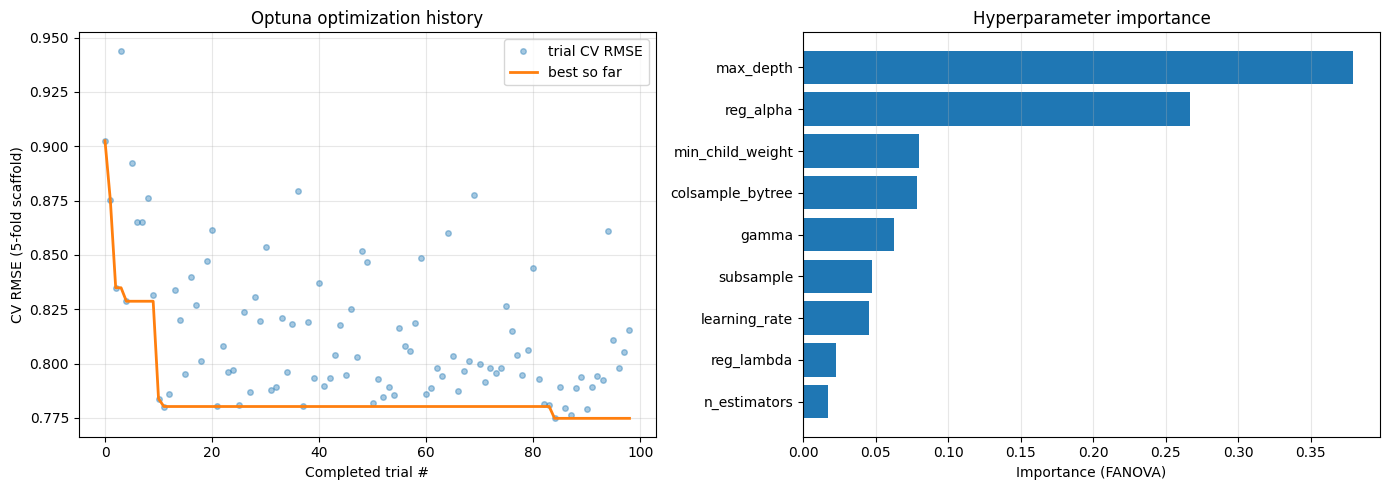

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Optimization history (best-so-far CV RMSE) ---
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
values = [t.value for t in completed]
best_so_far = np.minimum.accumulate(values)
axes[0].plot(range(len(values)), values, 'o', alpha=0.4, label='trial CV RMSE', markersize=4)
axes[0].plot(range(len(values)), best_so_far, '-', label='best so far', linewidth=2)
axes[0].set_xlabel('Completed trial #')
axes[0].set_ylabel('CV RMSE (5-fold scaffold)')
axes[0].set_title('Optuna optimization history')
axes[0].grid(alpha=0.3)
axes[0].legend()

# --- Parameter importances (FANOVA) ---
try:
    importances = optuna.importance.get_param_importances(study)
    names  = list(importances.keys())
    values_imp = list(importances.values())
    y_pos = np.arange(len(names))
    axes[1].barh(y_pos, values_imp)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(names)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Importance (FANOVA)')
    axes[1].set_title('Hyperparameter importance')
    axes[1].grid(alpha=0.3, axis='x')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Importance failed:\n{e}', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## 9. Refit best model on the full training set + evaluate on outer split

Take `study.best_params`, refit on the **full** (non-CV) training set of the outer split (seed=42),
then evaluate on train / valid / test exactly as in Phase 1/2.


In [ ]:
best_params = dict(study.best_params)

xgb_best = xgb.XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbosity=0,
)

t0 = time.time()
xgb_best.fit(X_train, y_train)
print(f"Refit on full training set in {time.time()-t0:.1f}s\n")

results_scaffold = {}
for name, X_, y_ in [('train', X_train, y_train),
                       ('valid', X_valid, y_valid),
                       ('test',  X_test,  y_test)]:
    results_scaffold[name] = evaluate(xgb_best, X_, y_, name)

print(f"Phase 3 — XGBoost (Optuna-tuned) — Scaffold split, seed={RANDOM_SEED}")
print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 32)
for name, r in results_scaffold.items():
    print(f"{name:<8} {r['RMSE']:>7.3f} {r['MAE']:>7.3f} {r['R2']:>7.3f}")


Refit on full training set in 15.9s

Phase 3 — XGBoost (Optuna-tuned) — Scaffold split, seed=42
Split       RMSE     MAE      R²
--------------------------------
train      0.111   0.085   0.997
valid      0.805   0.599   0.860
test       0.834   0.644   0.807


## 10. Multi-seed final evaluation

Best hyperparameters are kept fixed (chosen once on seed=42 outer split). Only the data split varies
with the seed `[42, 0, 1, 2, 3]`. This is the clean apples-to-apples comparison with Phase 1 / Phase 2,
and it lets us compute the **paired delta** (same seed = same split).

Note: re-tuning on each seed is a different (and more expensive) protocol — we are *not* doing that
here. We are testing the generalization of the chosen hyperparameters across scaffold splits.


In [ ]:
SCAFFOLD_SEEDS = [42, 0, 1, 2, 3]

xgb_runs = []

for seed in SCAFFOLD_SEEDS:
    tr_idx, va_idx, te_idx = scaffold_split_balanced(df, seed=seed)
    df_tr = df.loc[tr_idx].reset_index(drop=True)
    df_va = df.loc[va_idx].reset_index(drop=True)
    df_te = df.loc[te_idx].reset_index(drop=True)

    Xtr_full = featurize_combined(df_tr)
    Xva_full = featurize_combined(df_va)
    Xte_full = featurize_combined(df_te)
    ytr = df_tr['logS'].values
    yva = df_va['logS'].values
    yte = df_te['logS'].values

    medians_s, keep_s = fit_median_imputer(Xtr_full)
    Xtr = apply_imputer(Xtr_full, medians_s, keep_s)
    Xva = apply_imputer(Xva_full, medians_s, keep_s)
    Xte = apply_imputer(Xte_full, medians_s, keep_s)

    model = xgb.XGBRegressor(
        **best_params,
        objective='reg:squarederror',
        tree_method='hist',
        n_jobs=-1,
        random_state=RANDOM_SEED,  # XGB seed stays fixed; only split varies
        verbosity=0,
    )
    model.fit(Xtr, ytr)
    res_te = evaluate(model, Xte, yte, 'test')

    xgb_runs.append({
        'seed': seed,
        'RMSE': res_te['RMSE'],
        'MAE':  res_te['MAE'],
        'R2':   res_te['R2'],
        'test_size': len(df_te),
    })
    print(f"Seed {seed:>2}: test RMSE={res_te['RMSE']:.3f}  "
          f"MAE={res_te['MAE']:.3f}  R²={res_te['R2']:+.3f}  "
          f"(n_test={len(df_te)})")

rmses = np.array([r['RMSE'] for r in xgb_runs])
maes  = np.array([r['MAE']  for r in xgb_runs])
r2s   = np.array([r['R2']   for r in xgb_runs])

print(f"\nAggregate over {len(SCAFFOLD_SEEDS)} seeds:")
print(f"  RMSE = {rmses.mean():.3f} ± {rmses.std():.3f}")
print(f"  MAE  = {maes.mean():.3f} ± {maes.std():.3f}")
print(f"  R²   = {r2s.mean():+.3f} ± {r2s.std():.3f}")

# --- Random split for context (single seed) ---
indices = np.arange(len(df))
tr_idx_r, temp_idx = train_test_split(indices, test_size=0.2, random_state=RANDOM_SEED)
va_idx_r, te_idx_r = train_test_split(temp_idx, test_size=0.5, random_state=RANDOM_SEED)

df_tr_r = df.loc[tr_idx_r].reset_index(drop=True)
df_va_r = df.loc[va_idx_r].reset_index(drop=True)
df_te_r = df.loc[te_idx_r].reset_index(drop=True)

Xtr_r_full = featurize_combined(df_tr_r)
Xva_r_full = featurize_combined(df_va_r)
Xte_r_full = featurize_combined(df_te_r)
ytr_r = df_tr_r['logS'].values
yva_r = df_va_r['logS'].values
yte_r = df_te_r['logS'].values

medians_r, keep_r = fit_median_imputer(Xtr_r_full)
Xtr_r = apply_imputer(Xtr_r_full, medians_r, keep_r)
Xva_r = apply_imputer(Xva_r_full, medians_r, keep_r)
Xte_r = apply_imputer(Xte_r_full, medians_r, keep_r)

model_r = xgb.XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbosity=0,
)
model_r.fit(Xtr_r, ytr_r)
results_random = {
    'train': evaluate(model_r, Xtr_r, ytr_r, 'train'),
    'valid': evaluate(model_r, Xva_r, yva_r, 'valid'),
    'test':  evaluate(model_r, Xte_r, yte_r, 'test'),
}
print(f"\nRandom split (seed={RANDOM_SEED}) — XGBoost-tuned")
print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 32)
for name, r in results_random.items():
    print(f"{name:<8} {r['RMSE']:>7.3f} {r['MAE']:>7.3f} {r['R2']:>7.3f}")


Seed 42: test RMSE=0.834  MAE=0.644  R²=+0.807  (n_test=113)
Seed  0: test RMSE=0.867  MAE=0.657  R²=+0.794  (n_test=113)
Seed  1: test RMSE=0.838  MAE=0.649  R²=+0.802  (n_test=113)
Seed  2: test RMSE=0.862  MAE=0.635  R²=+0.839  (n_test=113)
Seed  3: test RMSE=0.907  MAE=0.700  R²=+0.792  (n_test=113)

Aggregate over 5 seeds:
  RMSE = 0.862 ± 0.026
  MAE  = 0.657 ± 0.023
  R²   = +0.807 ± 0.017

Random split (seed=42) — XGBoost-tuned
Split       RMSE     MAE      R²
--------------------------------
train      0.121   0.094   0.997
valid      0.606   0.411   0.898
test       0.550   0.392   0.936


## 11. Sugar bias check

Phase 2 finding: aggregate RMSE improved over Phase 1, but the model systematically under-predicted
solubility for poly-hydroxylated molecules (sugars, glycosides). The hypothesis was that this is
**structural to the featurization** (RDKit descriptors enabling a 'high MW + many rings → low logS'
shortcut), and would persist with any tabular model on the same features.

Verification on the seed=42 scaffold test set: top-5 worst residuals — are they still dominated
by sugars/glycosides?


In [17]:
yt = results_scaffold['test']['y_true']
yp = results_scaffold['test']['y_pred']
residuals = yp - yt          # sign convention: + means model over-predicts logS (predicts more soluble than truth)
                             #                  − means model under-predicts (predicts less soluble than truth)

df_test_with_pred = df_test.copy()
df_test_with_pred['logS_pred'] = yp
df_test_with_pred['residual']  = residuals
df_test_with_pred['abs_residual'] = np.abs(residuals)

# Top-5 worst residuals by |residual|
worst5 = df_test_with_pred.nlargest(5, 'abs_residual')[['smiles', 'logS', 'logS_pred', 'residual']]
print("Top-5 worst residuals on scaffold test set (seed=42), Phase 3 XGBoost-tuned:")
print(worst5.to_string(index=False))

# Stratify error by logS regime
print("\nError breakdown by true logS regime:")
print(f"{'Regime':<22} {'n':>4} {'RMSE':>7} {'MAE':>7} {'mean_resid':>11}")
print("-" * 55)
for label, mask in [
    ('hydrophilic (logS > -2)',   yt > -2),
    ('moderate (-4 < logS ≤ -2)', (yt > -4) & (yt <= -2)),
    ('hydrophobic (logS ≤ -4)',   yt <= -4),
]:
    if mask.sum() == 0:
        continue
    rmse_r = float(np.sqrt(mean_squared_error(yt[mask], yp[mask])))
    mae_r  = float(mean_absolute_error(yt[mask], yp[mask]))
    mres   = float(residuals[mask].mean())
    print(f"{label:<22} {mask.sum():>4} {rmse_r:>7.3f} {mae_r:>7.3f} {mres:>+11.3f}")


Top-5 worst residuals on scaffold test set (seed=42), Phase 3 XGBoost-tuned:
                                                               smiles   logS  logS_pred  residual
                                           O=C1c2ccccc2C(=O)c2ccccc21 -5.190  -2.661071  2.528929
                           CCOc1ccc(C(C)(C)COCc2cccc(Oc3ccccc3)c2)cc1 -8.600  -6.398195  2.201805
O=C1NC(=O)C2C3C(C(O)(c4ccccc4)c4ccccn4)=CC(C3=C(c3ccccc3)c3ccccn3)C12 -3.931  -6.054015 -2.123015
     ClC1(Cl)C2(Cl)C3(Cl)C4(Cl)C(Cl)(Cl)C5(Cl)C3(Cl)C1(Cl)C5(Cl)C24Cl -6.800  -8.797950 -1.997950
           OCC1OC(OCC2OC(OC3(CO)OC(CO)C(O)C3O)C(O)C(O)C2O)C(O)C(O)C1O -0.410  -2.290186 -1.880186

Error breakdown by true logS regime:
Regime                    n    RMSE     MAE  mean_resid
-------------------------------------------------------
hydrophilic (logS > -2)   18   0.825   0.625      -0.450
moderate (-4 < logS ≤ -2)   43   0.732   0.576      +0.018
hydrophobic (logS ≤ -4)   52   0.913   0.708      +0.219


**Reading the table**:
- `mean_resid` strongly negative on the hydrophilic regime ⟹ model under-predicts solubility for hydrophilic molecules (sugar bias persists).
- `mean_resid` close to zero on hydrophobic ⟹ no systematic bias on the regime where the model wins.
- Top-5 worst residuals: SMILES with multiple `OH`/`-O-` groups, often glycosidic, would confirm the same failure mode as Phase 2.

If the pattern holds → strong evidence that the **descriptor-based shortcut is the real cause**, not the model class.
ChemProp (Phase 5), which learns the representation end-to-end, is the right tool to break out of it.


## 12. Phase 1 vs Phase 2 vs Phase 3 — final comparison

Phase 1 and Phase 2 numbers come from the project context. Phase 3 numbers from this notebook.


In [ ]:
phase1 = {
    'Random split (seed=42)':   {'RMSE': 1.167, 'MAE': 0.899, 'R2': 0.712},
    'Scaffold (seed=42)':       {'RMSE': 1.618, 'MAE': 1.230, 'R2': 0.273},
    'Scaffold (5-seed mean)':   {'RMSE': 1.591, 'MAE': 1.239, 'R2': 0.344},
}
phase2 = {
    'Random split (seed=42)':   {'RMSE': 0.638, 'MAE': None,  'R2': 0.914},
    'Scaffold (seed=42)':       {'RMSE': 1.019, 'MAE': 0.765, 'R2': 0.712},
    'Scaffold (5-seed mean)':   {'RMSE': 1.062, 'MAE': 0.788, 'R2': 0.705},
}
phase3 = {
    'Random split (seed=42)':   {'RMSE': results_random['test']['RMSE'],
                                  'MAE': results_random['test']['MAE'],
                                  'R2':  results_random['test']['R2']},
    'Scaffold (seed=42)':       {'RMSE': results_scaffold['test']['RMSE'],
                                  'MAE': results_scaffold['test']['MAE'],
                                  'R2':  results_scaffold['test']['R2']},
    'Scaffold (5-seed mean)':   {'RMSE': float(rmses.mean()),
                                  'MAE': float(maes.mean()),
                                  'R2':  float(r2s.mean())},
}

print(f"{'Protocol':<28} {'P1 RMSE':>8} {'P2 RMSE':>8} {'P3 RMSE':>8}   "
      f"{'P1 R²':>7} {'P2 R²':>7} {'P3 R²':>7}")
print("-" * 90)
for proto in phase1:
    p1 = phase1[proto]; p2 = phase2[proto]; p3 = phase3[proto]
    print(f"{proto:<28} {p1['RMSE']:>8.3f} {p2['RMSE']:>8.3f} {p3['RMSE']:>8.3f}   "
          f"{p1['R2']:>7.3f} {p2['R2']:>7.3f} {p3['R2']:>7.3f}")

print(f"\n5-seed scaffold std (XGB-tuned): RMSE ± {rmses.std():.3f}, R² ± {r2s.std():.3f}")

# Save run summary as JSON for the README updater
summary = {
    'phase': 3,
    'model': 'XGBoost (Optuna-tuned)',
    'features': 'Morgan FP 2048 + RDKit 2D desc',
    'scaffold_seeds': SCAFFOLD_SEEDS,
    'random_split_seed42': phase3['Random split (seed=42)'],
    'scaffold_seed42':     phase3['Scaffold (seed=42)'],
    'scaffold_5seed_mean': phase3['Scaffold (5-seed mean)'],
    'scaffold_5seed_std':  {'RMSE': float(rmses.std()),
                             'MAE': float(maes.std()),
                             'R2':  float(r2s.std())},
    'best_params': best_params,
    'cv_best_rmse': study.best_value,
    'optuna_n_complete': n_complete,
    'optuna_n_pruned':   n_pruned,
    'optuna_elapsed_s':  t_opt,
}
with open(REPORTS_DIR / 'phase3_summary.json', 'w') as fh:
    json.dump(summary, fh, indent=2)
print(f"\nSaved → {REPORTS_DIR / 'phase3_summary.json'}")


Protocol                      P1 RMSE  P2 RMSE  P3 RMSE     P1 R²   P2 R²   P3 R²
------------------------------------------------------------------------------------------
Random split (seed=42)          1.167    0.638    0.550     0.712   0.914   0.936
Scaffold (seed=42)              1.618    1.019    0.834     0.273   0.712   0.807
Scaffold (5-seed mean)          1.591    1.062    0.862     0.344   0.705   0.807

5-seed scaffold std (XGB-tuned): RMSE ± 0.026, R² ± 0.017

Saved → /content/drive/MyDrive/qsar-esol-solubility/reports/phase3_summary.json


## 13. Paired Phase 2 → Phase 3 delta (RF vs XGB-tuned, same seeds)

To say *XGBoost-tuned beats RF*, the 5-seed delta must be computed paired (same seed = same split,
same train/valid/test molecules), then averaged. This is the same protocol used for the P1→P2 paired
delta in the project context.

Phase 2 per-seed RMSE numbers (from the project context, scaffold balanced):

    seed 42 → 1.019
    seed  0 → ~ (re-run if exact value not stored)
    seed  1 → ~
    seed  2 → ~
    seed  3 → ~

Mean ± std reported as 1.062 ± 0.053. If the exact per-seed Phase 2 RMSEs are not available in
the project context, **the rigorous thing to do is re-run notebook 02b once and store them**
(or extract them from the notebook 02b run cell output if it was preserved). Below we keep a
placeholder that the user can fill in once the per-seed numbers are recovered.


In [16]:
# Load Phase 2 per-seed results from JSON (saved by notebook 02b)
phase2_summary_path = REPORTS_DIR / 'phase2_summary.json'

if phase2_summary_path.exists():
    with open(phase2_summary_path) as fh:
        phase2_data = json.load(fh)
    # JSON keys are strings — convert back to int seeds
    phase2_per_seed_rmse = {
        int(seed): vals['RMSE']
        for seed, vals in phase2_data['per_seed'].items()
    }
    print(f"Loaded Phase 2 per-seed RMSE from {phase2_summary_path}")
else:
    print(f"⚠ {phase2_summary_path} not found.")
    print("Run the persistence cell at the end of notebook 02b first, then re-run this cell.")
    phase2_per_seed_rmse = {seed: None for seed in SCAFFOLD_SEEDS}

# ---- paired delta computation (unchanged from before) ----
phase3_per_seed_rmse = {r['seed']: r['RMSE'] for r in xgb_runs}

if all(v is not None for v in phase2_per_seed_rmse.values()):
    deltas = []
    print(f"\n{'Seed':>4}  {'P2 RMSE':>8}  {'P3 RMSE':>8}  {'Δ RMSE':>8}")
    print("-" * 40)
    for seed in SCAFFOLD_SEEDS:
        d = phase3_per_seed_rmse[seed] - phase2_per_seed_rmse[seed]
        deltas.append(d)
        print(f"{seed:>4}  {phase2_per_seed_rmse[seed]:>8.3f}  "
              f"{phase3_per_seed_rmse[seed]:>8.3f}  {d:>+8.3f}")
    deltas = np.array(deltas)
    print(f"\nPaired P2 → P3 delta: ΔRMSE = {deltas.mean():+.3f} ± {deltas.std():.3f}")
    print(f"P3 wins on {(deltas < 0).sum()}/{len(deltas)} seeds.")
else:
    print(f"\nPhase 3 per-seed RMSE: {phase3_per_seed_rmse}")
    print("Cannot compute paired delta until phase2_summary.json is available.")

Loaded Phase 2 per-seed RMSE from /content/drive/MyDrive/qsar-esol-solubility/reports/phase2_summary.json

Seed   P2 RMSE   P3 RMSE    Δ RMSE
----------------------------------------
  42     1.019     0.834    -0.184
   0     1.119     0.867    -0.252
   1     1.028     0.838    -0.190
   2     1.010     0.862    -0.148
   3     1.132     0.907    -0.225

Paired P2 → P3 delta: ΔRMSE = -0.200 ± 0.036
P3 wins on 5/5 seeds.


## 14. Parity plots (Phase 3)


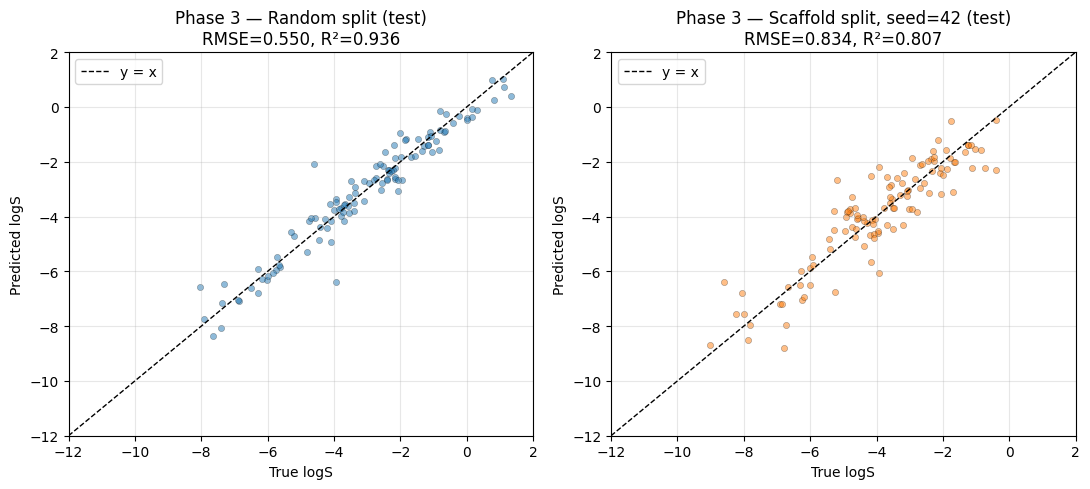

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

yt_r = results_random['test']['y_true']
yp_r = results_random['test']['y_pred']
axes[0].scatter(yt_r, yp_r, alpha=0.5, s=20, edgecolor='k', linewidth=0.3)
lim = [-12, 2]
axes[0].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('True logS'); axes[0].set_ylabel('Predicted logS')
axes[0].set_title(f"Phase 3 — Random split (test)\n"
                   f"RMSE={results_random['test']['RMSE']:.3f}, R²={results_random['test']['R2']:.3f}")
axes[0].grid(alpha=0.3); axes[0].legend(loc='upper left')

yt_s = results_scaffold['test']['y_true']
yp_s = results_scaffold['test']['y_pred']
axes[1].scatter(yt_s, yp_s, alpha=0.5, s=20, edgecolor='k', linewidth=0.3, color='tab:orange')
axes[1].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('True logS'); axes[1].set_ylabel('Predicted logS')
axes[1].set_title(f"Phase 3 — Scaffold split, seed=42 (test)\n"
                   f"RMSE={results_scaffold['test']['RMSE']:.3f}, R²={results_scaffold['test']['R2']:.3f}")
axes[1].grid(alpha=0.3); axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


## 15. Interpretation

_To fill in after the run completes._ Template:

- **Aggregate gain over Phase 2**: ΔRMSE on 5-seed scaffold mean. Hypothesis was ~0.05–0.10 RMSE improvement;
  the actual number tells whether 100 trials of Optuna were enough or whether the model was already saturated.
- **Sugar bias**: §11 confirms whether the failure mode is model-class or featurization. If the bias persists,
  ChemProp (Phase 5) becomes the next decisive test. If it shrinks, that's a surprise worth investigating
  (which hyperparameter mitigated it? `colsample_bytree` low? `reg_alpha` high pushing feature sparsity?).
- **Hyperparameter importance** (§8): tells which of the 9 knobs actually mattered on this dataset.
  Useful prior for the ADMET project, where running 9-param Optuna on every endpoint is expensive.
